In [15]:
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage

load_dotenv()

True

In [16]:
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(..., description="what to cover")

In [17]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [18]:
class State(TypedDict):
    topic: str
    plan: Plan
    # reducer
    sections: Annotated[List[str], operator.add]
    final: str

In [19]:
llm = ChatGroq(model="openai/gpt-oss-120b")

In [20]:
def orchestrator(state: State) -> dict:
    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "create a blog plan with 5-7 section on the following topic."
                )
            ),
            HumanMessage(content=f"Topic : {state['topic']}")
        ]
    )
    return {"plan": plan}

In [21]:
def fanout(state: State):
    return [
        Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
        for task in state["plan"].tasks
    ]

In [22]:
def worker(payload: dict) -> dict:
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]
    blog_title = plan.blog_title
    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(content=(
                f"Blog:{blog_title}\n"
                f"Topic:{topic}\n\n"
                f"section:{task.title}\n"
                f"Brief:{task.brief}\n\n"
                "Return only the section content in Markdown"
            ))
        ]
    ).content.strip()
    return {"sections": [section_md]}

In [23]:
from pathlib import Path

def reducer(state: State) -> dict:
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    clean_title = "".join(c if c.isalnum() or c in (" ", "_", "-") else "" for c in title)
    filename = clean_title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")
    return {"final": final_md}

In [24]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

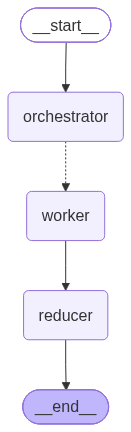

In [25]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [26]:
initial_state = {"topic": "Autonomous AI Agents with LangGraph"}
result = app.invoke(initial_state)

print("Blog Title:", result["plan"].blog_title)
print("Total Sections Generated:", len(result["sections"]))
print("\n--- Final Blog Content ---\n")
print(result["final"])

Blog Title: Building Autonomous AI Agents with LangGraph: A Practical Guide
Total Sections Generated: 7

--- Final Blog Content ---

# Building Autonomous AI Agents with LangGraph: A Practical Guide

## Introduction to Autonomous AI Agents

Autonomous AI agents are software entities that can perceive their environment, reason about goals, and take actions without continuous human supervision. Unlike traditional AI models that require explicit prompts for each task, autonomous agents:

- **Self‑direct**: They generate and prioritize their own sub‑tasks.
- **Adapt**: They react to dynamic inputs, updating plans on the fly.
- **Iterate**: They loop through observation → reasoning → action cycles until a goal is met.

### Why They Matter

1. **Scalability** – One agent can handle countless variations of a problem, reducing the need for handcrafted pipelines.
2. **Efficiency** – By automating decision‑making, organizations cut down on manual oversight and accelerate time‑to‑value.
3. **Comp